<a href="https://colab.research.google.com/github/toufiqrifat/parkinson-s-finger-tapping-/blob/main/finger_tapping_clean_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finger-Tapping Data Cleaning, Normalisation, and Feature Extraction

This notebook keeps the dataset upload / extraction point intact and fixes the processing pipeline so it is consistent, reproducible, and report-ready.


In [9]:
# 1. Imports
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


In [10]:
#2
import os
import zipfile

# Paths to the uploaded ZIP files
left_zip_path = "/content/LEFT HANDS-20260123T193134Z-1-001.zip"
right_zip_path = "/content/RIGHT HANDS-20260114T231452Z-1-001.zip"

# Extraction folders
extract_base = "/mnt/data/extracted"
LEFT_BASE = os.path.join(extract_base, "LEFT")
RIGHT_BASE = os.path.join(extract_base, "RIGHT")

# Create directories
os.makedirs(LEFT_BASE, exist_ok=True)
os.makedirs(RIGHT_BASE, exist_ok=True)

# Unzip LEFT data
with zipfile.ZipFile(left_zip_path, 'r') as zip_ref:
    zip_ref.extractall(LEFT_BASE)

# Unzip RIGHT data
with zipfile.ZipFile(right_zip_path, 'r') as zip_ref:
    zip_ref.extractall(RIGHT_BASE)

print("LEFT data extracted to:", LEFT_BASE)
print("RIGHT data extracted to:", RIGHT_BASE)

# Check folders
print("LEFT subjects:", os.listdir(LEFT_BASE)[:5])
print("RIGHT subjects:", os.listdir(RIGHT_BASE)[:5])


LEFT data extracted to: /mnt/data/extracted/LEFT
RIGHT data extracted to: /mnt/data/extracted/RIGHT
LEFT subjects: ['LEFT HANDS']
RIGHT subjects: ['RIGHT HANDS']


## 2. Utility Functions

These functions safely load signals, clean errors and noise, apply Min-Max normalisation, create report evidence, and extract features consistently.


In [11]:
# 3. File discovery and loading

def get_all_signal_files(base_path, extensions=(".txt", ".csv", ".dat")):
    """Recursively collect all supported signal files."""
    signal_files = []
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(tuple(ext.lower() for ext in extensions)):
                signal_files.append(os.path.join(root, file))
    return sorted(signal_files)


def load_signal(file_path):
    """Robust loader for 1D numeric signals."""
    candidates = [None, ",", ";", "	", " "]

    for delimiter in candidates:
        try:
            data = np.genfromtxt(file_path, delimiter=delimiter, dtype=float)
            if data is None:
                continue
            data = np.asarray(data, dtype=float)
            if data.size == 0:
                continue
            data = data.reshape(-1)
            if np.all(np.isnan(data)):
                continue
            return data
        except Exception:
            continue

    print(f"⚠️ Could not load: {file_path}")
    return None


def make_valid_odd_window(signal_length, desired_window=11):
    """Return a valid odd window length for Savitzky-Golay smoothing."""
    if signal_length < 3:
        return None
    window = min(desired_window, signal_length if signal_length % 2 == 1 else signal_length - 1)
    if window < 3:
        return None
    return window


def clean_and_normalise_signal(signal, smooth=True, desired_window=11, polyorder=2):
    """
    Clean a raw finger-tapping signal and scale it to 0-1.

    Steps:
    1. Convert to numeric 1D array
    2. Remove NaN and infinite values
    3. Remove obvious spikes using IQR clipping
    4. Smooth with Savitzky-Golay filter
    5. Apply Min-Max normalisation to [0, 1]
    """
    if signal is None:
        return None, None

    signal = np.asarray(signal, dtype=float).reshape(-1)
    signal = signal[np.isfinite(signal)]

    if signal.size < 3:
        return None, None

    raw_clean = signal.copy()

    q1, q3 = np.percentile(raw_clean, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clipped = np.clip(raw_clean, lower, upper)

    processed = clipped.copy()
    if smooth:
        window = make_valid_odd_window(len(processed), desired_window)
        if window is not None and window > polyorder:
            processed = savgol_filter(processed, window_length=window, polyorder=polyorder)

    scaler = MinMaxScaler(feature_range=(0, 1))
    normalised = scaler.fit_transform(processed.reshape(-1, 1)).reshape(-1)

    return processed, normalised


def plot_raw_vs_clean_vs_normalised(raw_signal, cleaned_signal, normalised_signal, title_prefix="Signal"):
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(raw_signal)
    axes[0].set_title(f"{title_prefix}: Raw Signal")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(cleaned_signal)
    axes[1].set_title(f"{title_prefix}: Cleaned Signal")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(normalised_signal)
    axes[2].set_title(f"{title_prefix}: Normalised Signal (0-1)")
    axes[2].set_xlabel("Time Step")
    axes[2].set_ylabel("Scaled Value")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def save_comparison_figure(raw_signal, cleaned_signal, normalised_signal, output_path, title_prefix="Signal"):
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(raw_signal)
    axes[0].set_title(f"{title_prefix}: Raw Signal")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(cleaned_signal)
    axes[1].set_title(f"{title_prefix}: Cleaned Signal")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(normalised_signal)
    axes[2].set_title(f"{title_prefix}: Normalised Signal (0-1)")
    axes[2].set_xlabel("Time Step")
    axes[2].set_ylabel("Scaled Value")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


## 3. Load Available Files


In [12]:
left_files = get_all_signal_files(LEFT_BASE)
right_files = get_all_signal_files(RIGHT_BASE)

print("Number of LEFT files:", len(left_files))
print("Number of RIGHT files:", len(right_files))

sample_file = left_files[0] if left_files else None
if sample_file:
    raw_signal = load_signal(sample_file)
    print("Loaded sample:", sample_file)
    print("Sample length:", None if raw_signal is None else len(raw_signal))
else:
    print("❌ No files found. Check upload / extraction paths.")


Number of LEFT files: 392
Number of RIGHT files: 394
Loaded sample: /mnt/data/extracted/LEFT/LEFT HANDS/C1/Text files/Amplitude.txt
Sample length: 1756


## 4. Clean and Normalise One Example

This cell produces the mandatory before/after evidence for the report.


Raw length: 1756
Cleaned length: 1756
Normalised min/max: 0.0 1.0


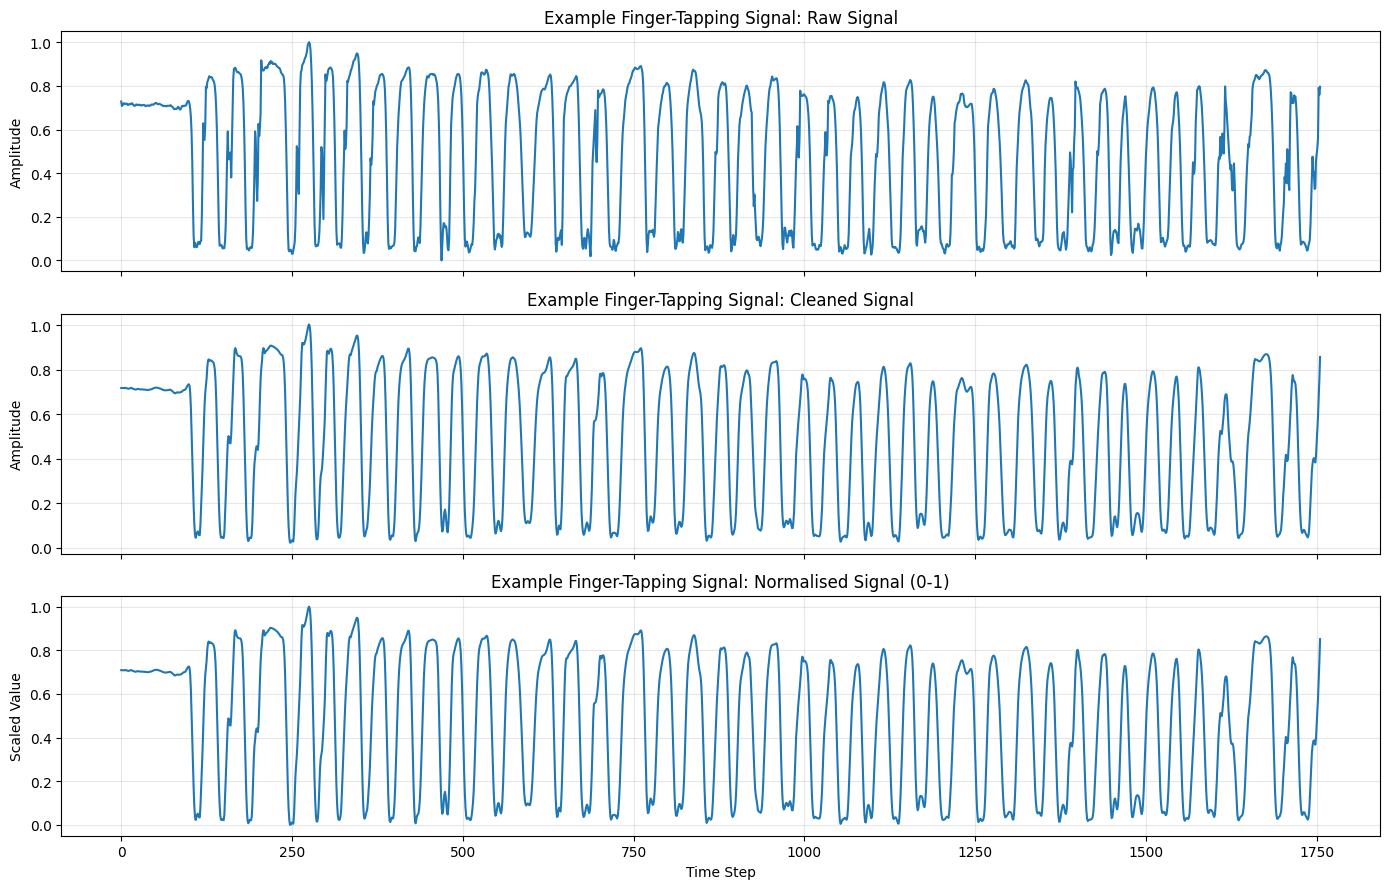

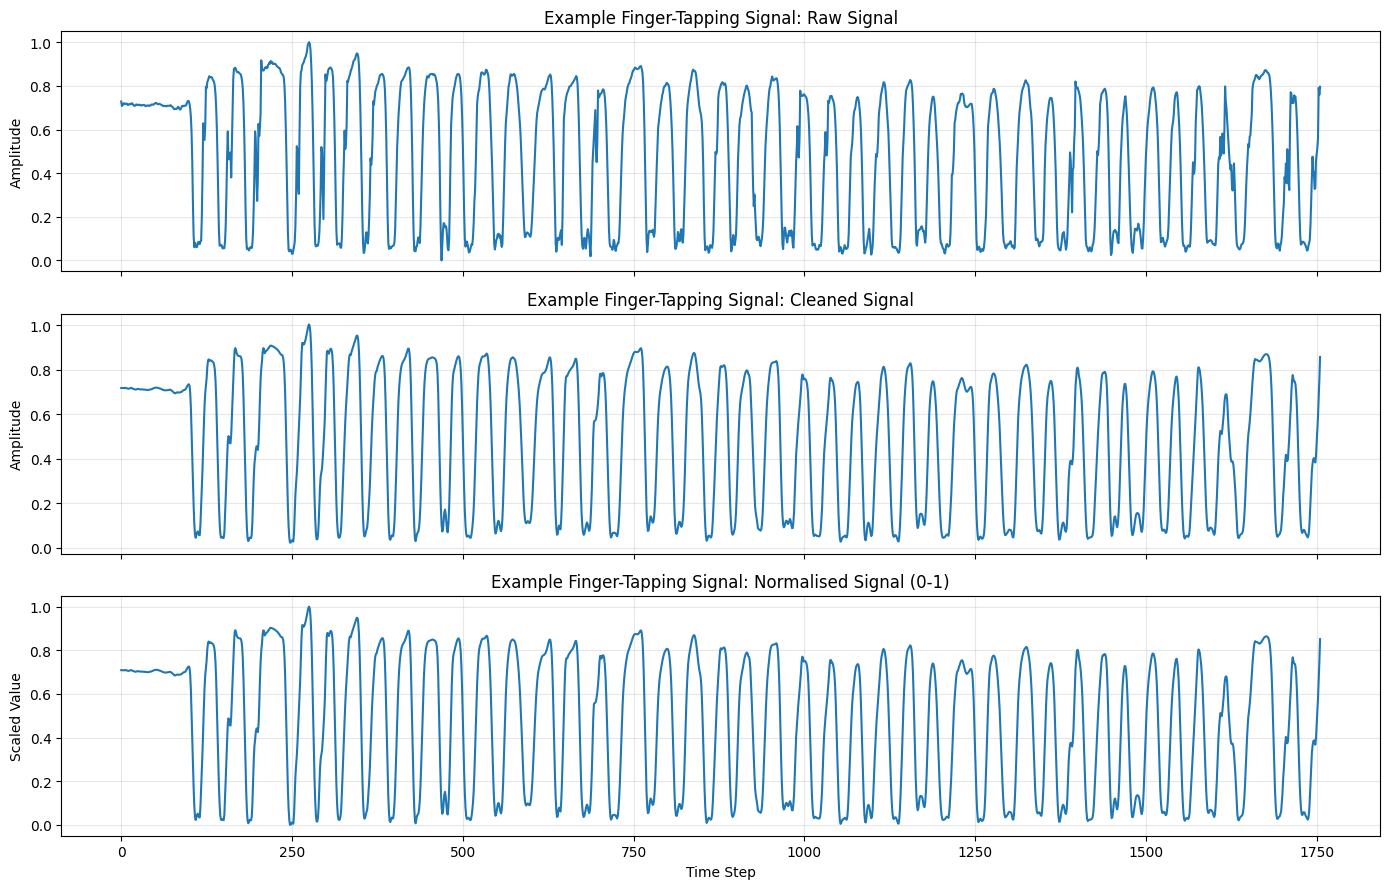

Saved evidence figure to: /mnt/data/raw_clean_normalised_comparison.png


In [13]:
cleaned_signal, normalised_signal = clean_and_normalise_signal(raw_signal)

if raw_signal is not None and cleaned_signal is not None and normalised_signal is not None:
    print("Raw length:", len(raw_signal))
    print("Cleaned length:", len(cleaned_signal))
    print("Normalised min/max:", np.min(normalised_signal), np.max(normalised_signal))

    plot_raw_vs_clean_vs_normalised(raw_signal, cleaned_signal, normalised_signal, title_prefix="Example Finger-Tapping Signal")

    evidence_path = "/mnt/data/raw_clean_normalised_comparison.png"
    save_comparison_figure(raw_signal, cleaned_signal, normalised_signal, evidence_path, title_prefix="Example Finger-Tapping Signal")
    print("Saved evidence figure to:", evidence_path)
else:
    print("❌ Sample signal could not be cleaned. Check file format/content.")


## 5. Feature Engineering


In [14]:
def compute_velocity(signal):
    """First derivative of the normalised signal."""
    if signal is None or len(signal) < 2:
        return None
    return np.gradient(signal)


def safe_entropy(signal, bins=20):
    """Histogram-based entropy with safe zero handling."""
    hist, _ = np.histogram(signal, bins=bins, density=False)
    probs = hist / np.sum(hist) if np.sum(hist) > 0 else hist
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs + 1e-12)) if probs.size > 0 else 0.0


def extract_amplitude_features(signal):
    return {
        "amp_mean": float(np.mean(signal)),
        "amp_std": float(np.std(signal)),
        "amp_max": float(np.max(signal)),
        "amp_min": float(np.min(signal)),
        "amp_range": float(np.max(signal) - np.min(signal)),
        "amp_median": float(np.median(signal)),
        "amp_iqr": float(np.percentile(signal, 75) - np.percentile(signal, 25)),
        "amp_energy": float(np.sum(signal ** 2))
    }


def extract_velocity_features(velocity):
    return {
        "vel_mean": float(np.mean(velocity)),
        "vel_std": float(np.std(velocity)),
        "vel_max": float(np.max(velocity)),
        "vel_min": float(np.min(velocity)),
        "vel_range": float(np.max(velocity) - np.min(velocity)),
        "vel_energy": float(np.sum(velocity ** 2))
    }


def extract_rhythm_features(signal):
    centered = signal - np.mean(signal)
    zero_crossings = np.where(np.diff(np.sign(centered)) != 0)[0]
    return {
        "zero_crossing_rate": float(len(zero_crossings) / len(signal)),
        "signal_energy": float(np.sum(signal ** 2)),
        "signal_entropy": float(safe_entropy(signal, bins=20))
    }


## 6. Process the Full Dataset


In [20]:
def process_dataset(file_list, label):
    dataset_rows = []

    for file_path in file_list:
        raw_signal = load_signal(file_path)
        cleaned_signal, normalised_signal = clean_and_normalise_signal(raw_signal)

        if normalised_signal is None or len(normalised_signal) < 364:
            continue

        velocity = compute_velocity(normalised_signal)
        if velocity is None:
            continue

        features = {}
        features.update(extract_amplitude_features(normalised_signal))
        features.update(extract_velocity_features(velocity))
        features.update(extract_rhythm_features(normalised_signal))
        features["label"] = label
        features["file_name"] = os.path.basename(file_path)
        features["original_length"] = len(raw_signal) if raw_signal is not None else np.nan
        features["processed_length"] = len(normalised_signal)

        dataset_rows.append(features)

    return dataset_rows


left_dataset = process_dataset(left_files, label="left")
right_dataset = process_dataset(right_files, label="right")

features_df = pd.DataFrame(left_dataset + right_dataset)

print("Final feature dataset shape:", features_df.shape)
features_df.head()


Final feature dataset shape: (590, 21)


,amp_mean,amp_std,amp_max,amp_min,amp_range,amp_median,amp_iqr,amp_energy,vel_mean,vel_std,vel_max,vel_min,vel_range,vel_energy,zero_crossing_rate,signal_energy,signal_entropy,label,file_name,original_length,processed_length
0,0.462090,0.311243,1.0,0.0,1.0,0.522533,0.638123,545.060664,0.000110,5.315896e-02,0.133632,-0.155195,2.888269e-01,4.962259,0.047836,545.060664,2.762484,left,Amplitude.txt,1756,1756
1,0.500461,0.288874,1.0,0.0,1.0,0.501112,0.499583,586.344703,0.000570,4.270380e-05,0.001004,0.000463,5.416114e-04,0.000573,0.000569,586.344703,2.995611,left,Time.txt,1756,1756
2,0.516020,0.218673,1.0,0.0,1.0,0.525081,0.216589,551.236214,0.000055,5.961762e-02,0.156013,-0.152695,3.087084e-01,6.237734,0.105413,551.236214,2.726836,left,Velocity.txt,1755,1755
3,0.574835,0.376419,1.0,0.0,1.0,0.717613,0.817282,849.827444,-0.000031,6.019403e-02,0.165580,-0.162978,3.285588e-01,6.521980,0.038889,849.827444,2.531618,left,Amplitude.txt,1800,1800
4,0.500000,0.288836,1.0,0.0,1.0,0.500000,0.500000,600.166759,0.000556,6.948699e-17,0.000556,0.000556,1.776357e-15,0.000556,0.000556,600.166759,2.995732,left,Time.txt,1800,1800


## 7. Mandatory Evidence: Before and After Normalisation Tables

The brief asks for datasets before and after normalisation. This cell creates small report-ready tables.


In [16]:
if raw_signal is not None and cleaned_signal is not None and normalised_signal is not None:
    before_df = pd.DataFrame({"raw_signal": raw_signal[:20]})
    after_df = pd.DataFrame({
        "cleaned_signal": cleaned_signal[:20],
        "normalised_signal": normalised_signal[:20]
    })

    print("Before normalisation (first 20 rows):")
    display(before_df)
    print("After cleaning and normalisation (first 20 rows):")
    display(after_df)
else:
    print("No sample data available for before/after tables.")


Before normalisation (first 20 rows):


,raw_signal
0,0.728334
1,0.707412
2,0.711294
3,0.717946
4,0.720615
5,0.717337
6,0.717561
7,0.718587
8,0.719047
9,0.713244


After cleaning and normalisation (first 20 rows):


,cleaned_signal,normalised_signal
0,0.717752,0.708722
1,0.717755,0.708725
2,0.717688,0.708656
3,0.717551,0.708516
4,0.717343,0.708305
5,0.717066,0.708022
6,0.718904,0.709895
7,0.717629,0.708596
8,0.716323,0.707265
9,0.715405,0.706329


## 8. Save Outputs

This makes it easier to attach tables and figures to the report.


In [17]:
if not features_df.empty:
    features_output = "/mnt/data/finger_tapping_features.csv"
    features_df.to_csv(features_output, index=False)
    print("Saved feature dataset to:", features_output)

if raw_signal is not None and cleaned_signal is not None and normalised_signal is not None:
    before_df.to_csv("/mnt/data/before_normalisation_sample.csv", index=False)
    after_df.to_csv("/mnt/data/after_normalisation_sample.csv", index=False)
    print("Saved before/after normalisation samples to /mnt/data")


Saved feature dataset to: /mnt/data/finger_tapping_features.csv
Saved before/after normalisation samples to /mnt/data
